Карта Мира
Есть набор данных, который содержит информацию из Wiki о нескольких важных городах:

Координаты (в формате угловые градусы, минуты, секунды)
Название страны
Признак столицы (1 - столица, 0 - нет)
Название города
Обратите внимание, что:

градусы северной широты - положительные
градусы южной широты - отрицательные
градусы восточной долготы - положительные
градусы западной долготы - отрицательные
Т.е. мы считаем, что нулевой меридиан и нулевая параллель пересекаются в центре карты. Для задания можете использовать эту карту (или любую иную, которая вам понравится, но пожалуйста приложите её к решению).

Отметьте на карте города, согласно их координатам, если их население больше 1.000.000 человек (размер маркера должен быть пропорционален населению).

Столицы отметьте одним маркером (например, звёздочкой), а обычные города другим (например, кружком).

Цвета всех городов одной страны должны совпадать.

Используйте цвета (если вы используете случайную генерацию цвета, то допускается случайная оптическая близость цветов нескольких стран, но старайтесь чтобы их было не больше половины, а так же, чтобы отметки были различимы на карте).


P.S. Для определения где находится на карте точка, в соответствии с её угловыми координатами может пригодиться статьи на Хабре и Wiki.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

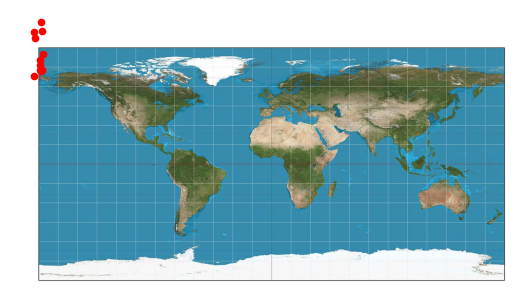

In [36]:
# https://medium.com/@suverov.dmitriy/how-to-convert-latitude-and-longitude-coordinates-into-pixel-offsets-8461093cb9f5

cities = pd.read_csv("cities.csv", encoding="UTF-8")
big_cities = cities[cities["Population"] > 1_000_000]

world_map = plt.imread("world_map.jpg")
height, width = world_map.shape[:2]

width_coef = width / 360
height_coef = height / 360

def convert_coordinates_to_decimal(degree, minute, second):
    if degree < 0:
        return degree - minute / 60 - second / 3600
    return degree + minute / 60 + second / 3600

points = []
for _, line in big_cities.iterrows():
    x_decimal = convert_coordinates_to_decimal(line["Longitude deg"], line["Longitude min"], line["Longitude sec"])
    x_decimal = convert_coordinates_to_decimal(line["Latitude deg"], line["Latitude min"], line["Latitude sec"])
    points.append([x_decimal, y_decimal])


plt.imshow(world_map)
plt.axis('off')
for x, y in points:
    plt.scatter(x, y, color='red', marker='o', s=20)

plt.show()